# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 1. Метрики и меры схожести между временными рядами.**

Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы первой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [2]:
import os

practice_dir_path = 'C:/Users/SlunKing/Desktop/2025-Sukhorukov-TimeSeriesCourse-main/practice/01 Basics'
os.chdir(practice_dir_path)

Выполните команды, которые автоматически перезагружают все импортированные модули при их изменении.

In [3]:
%load_ext autoreload
%autoreload 2

Импортируйте библиотеки и модули, необходимые для реализации практической работы 1.

In [4]:
import numpy as np
import random
from sktime.distances import euclidean_distance, dtw_distance, pairwise_distance
from sklearn.metrics import silhouette_score
import cv2
import imutils
import glob
import matplotlib.pyplot as plt
import pandas as pd

from modules.metrics import ED_distance, norm_ED_distance, DTW_distance
from modules.pairwise_distance import PairwiseDistance
from modules.clustering import TimeSeriesHierarchicalClustering
from modules.classification import TimeSeriesKNN, calculate_accuracy
from modules.image_converter import Image2TimeSeries
from modules.utils import read_ts, z_normalize, sliding_window, random_walk
from modules.plots import plot_ts

## **Часть 1.** Функции расстояния: евклидова метрика и DTW мера. Матрица расстояний. Иерархическая кластеризация временных рядов.

### **Задача 1.**
Реализуйте самостоятельно функцию `ED_distance()` в модуле *metrics.py*, которая вычисляет евклидово расстояние между двумя временными рядами, имеющими одинаковую длину. В качестве входных данных передайте в функцию два синтетических временных ряда некоторой заданной вами длины. Для их генерации используйте функцию `random_walk()` из модуля *utils.py*,  реализующую модель случайных блужданий (Random Walk), или стандартный модуль *random*.

**Евклидово расстояние** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
    \text{ED}(T_1, T_2) = \sqrt{\sum_{i=1}^{n} ({t_{1}}_i-{t_{2}}_i)^2}.
\end{equation}

Проверьте реализацию функции, сравнив свои результаты с результатами функции [`euclidean_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, с помощью `test_distances()`.

In [50]:
def test_distances(dist1: float, dist2: float) -> None:
    """
    Check whether your distance function is implemented correctly

    Parameters
    ----------
    dist1 : distance between two time series calculated by sktime
    dist2 : distance between two time series calculated by your function
    """

    np.testing.assert_equal(round(dist1, 5), round(dist2, 5), 'Distances are not equal')

In [51]:
# Генерируем два временных ряда длиной 100 с помощью random_walk
ts_length = 100
ts1 = random_walk(ts_length)
ts2 = random_walk(ts_length)

print("Длина временных рядов:", len(ts1))
print("Временной ряд 1 (первые 10 значений):", ts1[:10])
print("Временной ряд 2 (первые 10 значений):", ts2[:10])

# Вычисляем расстояние с помощью sktime
dist_sktime = euclidean_distance(ts1, ts2)
print(f"Расстояние (sktime): {dist_sktime:.6f}")

# Вычисляем расстояние с помощью функции ED_distance
dist_custom = ED_distance(ts1, ts2)
print(f"Расстояние (ED_distance): {dist_custom:.6f}")

Длина временных рядов: 100
Временной ряд 1 (первые 10 значений): [ 0 -1 -2 -1 -2 -1 -2 -1 -2 -3]
Временной ряд 2 (первые 10 значений): [0 1 2 1 2 3 2 1 0 1]
Расстояние (sktime): 79.949984
Расстояние (ED_distance): 79.949984


### **Задача 2.**

Реализуйте самостоятельно функцию `DTW_distance()` в модуле *metrics.py*, которая вычисляет DTW расстояние между двумя временными рядами, имеющими одинаковую длину. Для вычисления расстояния между элементами временных рядов в DTW мере используйте евклидово расстояние. Временные ряды сгенерируйте аналогичным образом, как в задаче 1, или используйте уже созданные.

**Динамическая трансформация временной шкалы (Dynamic Time Warping, DTW)** – мера схожести между двумя временными рядами $T_1$ и $T_2$ длины $n$, вычисляемая следующим образом:

\begin{equation}
\text{DTW}(T_1, T_2) = d(n,n),
\\ d(i,j) = ({t_{1}}_i - {t_{2}}_j)^2 + \min \left\{
	\begin{array}{l l}
	d(i-1,j), \\
	d(i,j-1), \\
	d(i-1,j-1),
	\end{array}
	\right.
\\ d(0,0)=0, \quad d(i,0)=d(0,j)=\infty, \quad  1 \leqslant i,j \leqslant n.
\end{equation}

Сравните свои результаты с результатами функции [`dtw_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.dtw_distance.html) из библиотеки *sktime*. Для этого используйте `test_distances()` из задачи 1.

In [52]:
# Генерируем два временных ряда
ts_length = 50  # Используем меньшую длину для DTW (вычисление интенсивнее)
ts1 = random_walk(ts_length)
ts2 = random_walk(ts_length)

print("Длина временных рядов:", len(ts1))
print("Временной ряд 1 (первые 10 значений):", ts1[:10])
print("Временной ряд 2 (первые 10 значений):", ts2[:10])

# Вычисляем DTW расстояние с помощью sktime
dist_sktime = dtw_distance(ts1, ts2)
print(f"DTW расстояние (sktime): {dist_sktime:.6f}")

# Вычисляем DTW расстояние с помощью  функции DTW_distance
dist_custom = DTW_distance(ts1, ts2, r=1.0)  # r=1.0 означает нет окна (полный поиск)
print(f"DTW расстояние (функция DTW_distance): {dist_custom:.6f}")


Длина временных рядов: 50
Временной ряд 1 (первые 10 значений): [0 1 2 3 4 3 2 1 2 3]
Временной ряд 2 (первые 10 значений): [ 0  1  0 -1  0 -1  0  1  2  1]
DTW расстояние (sktime): 184.000000
DTW расстояние (функция DTW_distance): 184.000000


### **Задача 3.**
Реализуйте нахождение матрицы расстояний между несколькими временными рядами.
Для этого заполните все методы c недостающим кодом в классе `PairwiseDistance` из модуля *pairwise_distance.py*. Для вычисления расстояний между рядами используйте ранее реализованные вами функции `ED_distance()` и `DTW_distance()` из модуля *metrics.py*.

Матрица расстояний между временными рядами определяется следующим образом. Пусть дано множество $S$, состоящее из $K$ временных рядов длины $n$: $\;S = \{T_1, T_2, ..., T_K\}, \; T_i \in \mathbb{R}^n$. Тогда под **матрицей расстояний** $D \in \mathbb{R}^{K \times K}$ понимается квадратная матрица, где каждый ее элемент $d(i,j)$ представляет собой расстояние между временными рядами $T_i$ и $T_j$ из множества $S$:
\begin{equation}
d(i,j) = dist(T_i, T_j), \quad T_i, T_j \in S, \quad 1 \leqslant i,j \leqslant K.
\end{equation}

Поскольку евклидова метрика и DTW мера удовлетворяют аксиоме симметричности (т.е. $dist(T_i, T_j)=dist(T_j, T_i)$), то матрица расстояний $D$ будет симметричной относительно главной диагонали. Для ускорения вычислений достаточно найти ее верхний треугольник, а нижний треугольник матрицы заполнить значениями верхнего треугольника следующим образом:
\begin{equation}
d(j,i) = d(i,j), \; где \; i < j.
\end{equation}

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/distance_matrix.png?raw=true" width="600"></center>

Сгенерируйте множество, состоящее из $K$ временных рядов некоторой длины $n$. Вычислите матрицы евклидовых и DTW расстояний между ними. Проверьте реализованные вами методы, сравнив свои результаты с результатами функции [`pairwise_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.pairwise_distance.html) из библиотеки *sktime*.

In [53]:
def test_matrices(matrix1 : np.ndarray, matrix2 : np.ndarray) -> None:
    """
    Check whether your matrix function is implemented correctly

    Parameters
    ----------
    matrix1 : distance matrix calculated by sktime
    matrix2 : distance matrix calculated by your function
    """

    np.testing.assert_equal(matrix1.round(5), matrix2.round(5), 'Matrices are not equal')

In [54]:
# Генерируем множество временных рядов
K = 5  # количество временных рядов
n = 20  # длина каждого временного ряда

# Создаем набор временных рядов
time_series_set = np.array([random_walk(n) for _ in range(K)])

print(f"Размерность набора данных: {time_series_set.shape}")
print(f"Количество временных рядов: {K}")
print(f"Длина каждого ряда: {n}")
print("\n")

# Тестирование евклидовой матрицы расстояний
print("Тестирование евклидовой матрицы расстояний:")

# Наша реализация
euclidean_calculator = PairwiseDistance(metric='euclidean', is_normalize=False)
euclidean_matrix_custom = euclidean_calculator.calculate(time_series_set)

# Sktime реализация
euclidean_matrix_sktime = pairwise_distance(time_series_set, metric='euclidean')

print("Наша матрица евклидовых расстояний:")
print(euclidean_matrix_custom)
print("\nSktime матрица евклидовых расстояний:")
print(euclidean_matrix_sktime)

# Проверка совпадения
print(f"\nМатрицы совпадают: {np.allclose(euclidean_matrix_custom, euclidean_matrix_sktime, atol=1e-10)}")
print("\n")

# Тестирование DTW матрицы расстояний
print("Тестирование DTW матрицы расстояний:")

# Наша реализация
dtw_calculator = PairwiseDistance(metric='dtw', is_normalize=False)
dtw_matrix_custom = dtw_calculator.calculate(time_series_set)

# Sktime реализация
dtw_matrix_sktime = pairwise_distance(time_series_set, metric='dtw')

print("Наша матрица DTW расстояний:")
print(dtw_matrix_custom)
print("\nSktime матрица DTW расстояний:")
print(dtw_matrix_sktime)

# Проверка совпадения
print(f"\nМатрицы совпадают: {np.allclose(dtw_matrix_custom, dtw_matrix_sktime, atol=1e-10)}")



Размерность набора данных: (5, 20)
Количество временных рядов: 5
Длина каждого ряда: 20


Тестирование евклидовой матрицы расстояний:
Наша матрица евклидовых расстояний:
[[ 0.          7.21110255 10.19803903 18.33030278 19.79898987]
 [ 7.21110255  0.         11.83215957 18.         17.77638883]
 [10.19803903 11.83215957  0.         12.64911064 13.26649916]
 [18.33030278 18.         12.64911064  0.         12.        ]
 [19.79898987 17.77638883 13.26649916 12.          0.        ]]

Sktime матрица евклидовых расстояний:
[[ 0.          7.21110255 10.19803903 18.33030278 19.79898987]
 [ 7.21110255  0.         11.83215957 18.         17.77638883]
 [10.19803903 11.83215957  0.         12.64911064 13.26649916]
 [18.33030278 18.         12.64911064  0.         12.        ]
 [19.79898987 17.77638883 13.26649916 12.          0.        ]]

Матрицы совпадают: True


Тестирование DTW матрицы расстояний:
Наша матрица DTW расстояний:
[[  0.  10.  78. 256. 334.]
 [ 10.   0.  84. 246. 300.]
 [ 78.  84

### **Задача 4.**
Далее рассмотрим задачу иерархической кластеризации временных рядов, где будет использоваться предвычисленная матрица расстояний.

Для этого сначала загрузите набор временных рядов CBF из файла *CBF_TRAIN.txt*, который располагается в директории *./datasets/part1*. Каждая строка данного файла содержит целевую переменную (класс: 0, 1 или 2) в первом столбце и временной ряд в остальных столбцах. Набор CBF является синтетическим и включает в себя 30 временных рядов,  каждый из которых принадлежит к одному из трех классов.

In [55]:
url = 'C:/Users/SlunKing/Desktop/2025-Sukhorukov-TimeSeriesCourse-main/practice/01 Basics/datasets/part1/CBF_TRAIN.txt'

data = read_ts(url)

ts_set = data[:, 1:]
labels = data[:, 0]

print(f"Размерность данных: {ts_set.shape}")
print(f"Уникальные метки: {np.unique(labels)}")
print(f"Количество примеров каждого класса: {np.bincount(labels.astype(int))}")

Размерность данных: (30, 128)
Уникальные метки: [1. 2. 3.]
Количество примеров каждого класса: [ 0 10 12  8]


Выполните визуализацию по одному временному ряду из каждого класса. Для этого используйте функцию `plot_ts()` из модуля *plots.py*.

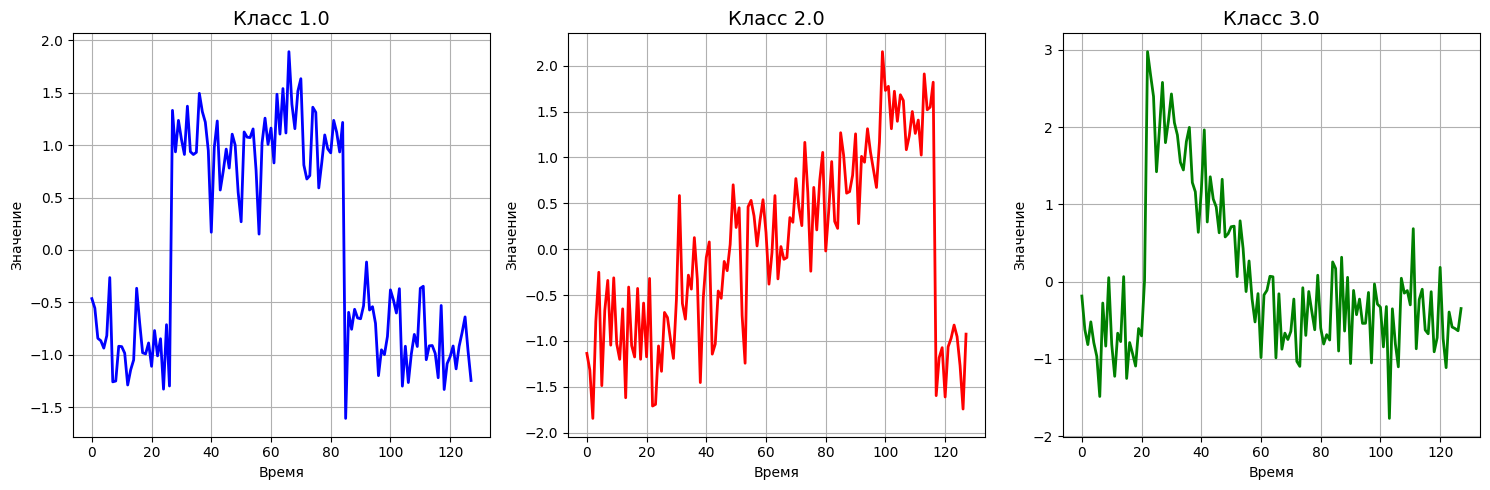

In [56]:
# Визуализация по одному временному ряду из каждого класса
plt.figure(figsize=(15, 5))
unique_labels = np.unique(labels)
colors = ['blue', 'red', 'green']

for i, label in enumerate(unique_labels):
    # Находим первый временной ряд с этой меткой
    idx = np.where(labels == label)[0][0]
    plt.subplot(1, 3, i+1)
    plt.plot(ts_set[idx], color=colors[i], linewidth=2)
    plt.title(f'Класс {label}', fontsize=14)
    plt.xlabel('Время')
    plt.ylabel('Значение')
    plt.grid(True)
    
plt.tight_layout()
plt.show()

Далее самостоятельно реализуйте класс `TimeSeriesHierarchicalClustering` из модуля *clustering.py*, который выполняет иерархическую кластеризацию временных рядов.

Перед тем как приступить к реализации, изучите скелет этого класса. Реализуйте метод `fit()`, выполняющий кластеризацию данных на основе предвычисленной матрицы расстояний, которая передается в данный метод. Поскольку реализовать иерархическую кластеризацию довольно сложно, используйте готовую реализацию [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) из *sklearn*.   

Выполните иерархическую кластеризацию загруженных временных рядов CBF для двух функций расстояния: евлидовой метрики и DTW меры.
Для этого сначала найдите матрицы расстояний между временными рядами, используя класс `PairwiseDistance`, и передайте каждую матрицу в метод `fit()` для кластеризации.
Далее выполните визуализацию результатов в виде дендрограмм с помощью метода `plot_dendrogram()`, передав исходный набор временных рядов и их метки.

Вычисляем матрицу евклидовых расстояний...
Вычисляем матрицу DTW расстояний...
Кластеризация с евклидовым расстоянием...
Кластеризация с DTW расстоянием...
Визуализация дендрограмм...


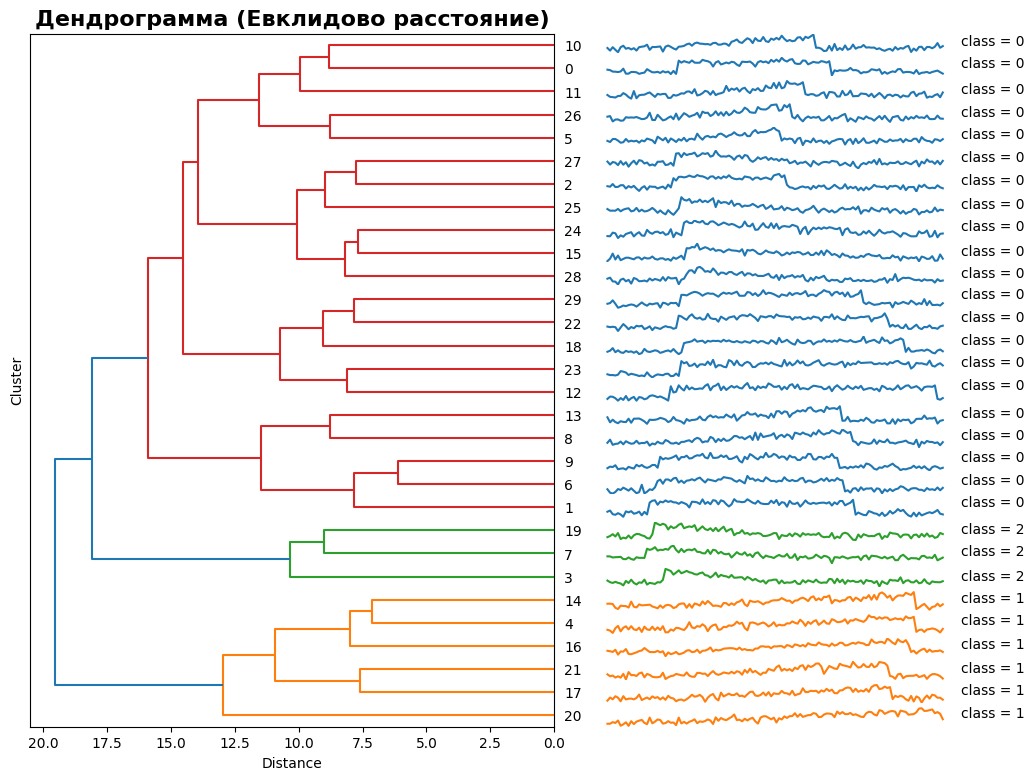

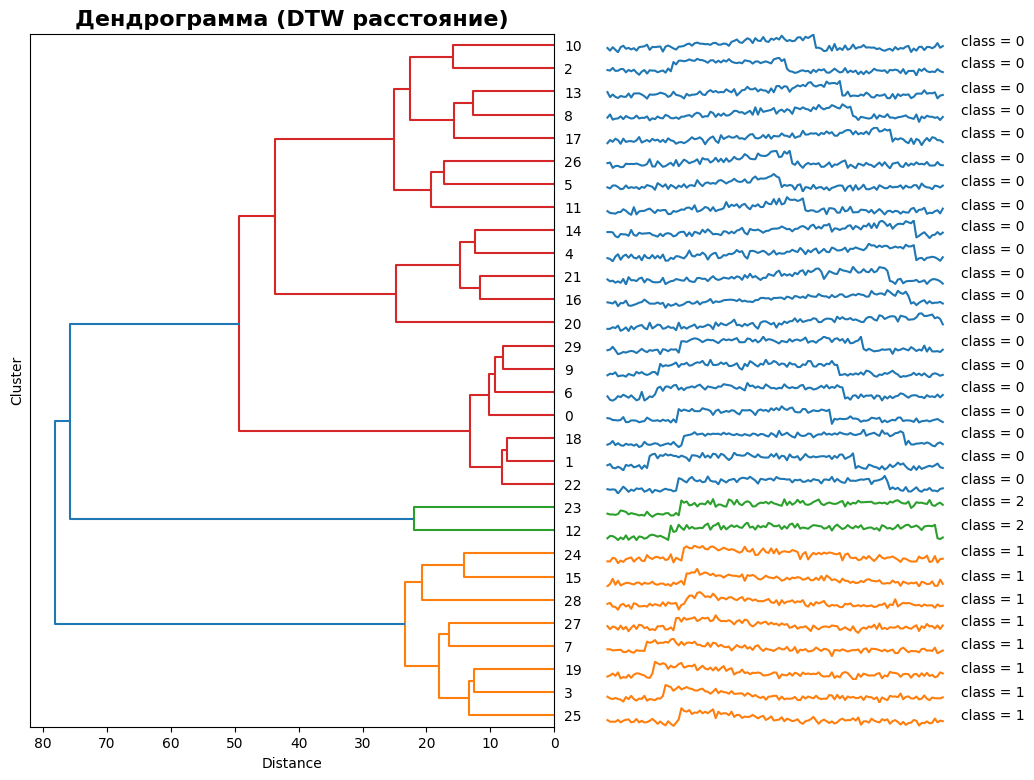

In [57]:
# Создаем DataFrame для plot_dendrogram
df_ts = pd.DataFrame(ts_set.T)  # транспонируем для правильного формата

# Вычисляем матрицы расстояний
print("Вычисляем матрицу евклидовых расстояний...")
euclidean_calc = PairwiseDistance(metric='euclidean')
euclidean_matrix = euclidean_calc.calculate(ts_set)

print("Вычисляем матрицу DTW расстояний...")
dtw_calc = PairwiseDistance(metric='dtw')
dtw_matrix = dtw_calc.calculate(ts_set)

# Кластеризация с евклидовым расстоянием
print("Кластеризация с евклидовым расстоянием...")
hc_euclidean = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
hc_euclidean.fit(euclidean_matrix)
labels_euclidean = hc_euclidean.labels_

# Кластеризация с DTW расстоянием
print("Кластеризация с DTW расстоянием...")
hc_dtw = TimeSeriesHierarchicalClustering(n_clusters=3, method='complete')
hc_dtw.fit(dtw_matrix)
labels_dtw = hc_dtw.labels_

# Визуализация дендрограмм
print("Визуализация дендрограмм...")

# Дендрограмма для евклидового расстояния
hc_euclidean.plot_dendrogram(df_ts, labels_euclidean, 
                            title='Дендрограмма (Евклидово расстояние)')

# Дендрограмма для DTW расстояния
hc_dtw.plot_dendrogram(df_ts, labels_dtw,
                      title='Дендрограмма (DTW расстояние)')

plt.show()

Сравните результаты иерархической кластеризации, полученные при двух различных функций расстояния, с помощью силуэтного коэффициента. Для этого используйте функцию [`silhouette_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) из библиотеки *sklearn*, передав в нее предвычисленную матрицу расстояний и предсказанные метки.

**Силуэтный коэффициент** – метрика, которая оценивает качество кластеризации на основе исходной выборки и результатов кластеризации без необходимости знания об истинных метках объектов.

Силуэтный коэффициент для выборки показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров. Пусть дана выборка $X$, состоящая из $N$ объектов. Предположим, что объекты этой выборки были разбиты на кластеры $c_1, ... c_K$, $c_i \in C$, с помощью некоторого алгоритма кластеризации. Тогда силуэтный коэффициент для выборки будет вычисляться следующим образом:

\begin{equation}
sil\_coef = \frac{1}{N} \sum_{c_k \in C} \sum_{x_i \in c_k} \frac{b(x_i, c_k) - a(x_i, c_k)}{\max(a(x_i, c_k), b(x_i, c_k))},
\end{equation}

где $a(x_i, c_k)$ – среднее расстояние от объекта $x_i \in c_k$ до других объектов из этого же кластера $c_k$; <br> $b(x_i, c_k)$  – среднее расстояние от объекта $x_i \in c_k$ до объектов из другого кластера $c_l$, $k \neq l$.

Силуэтный коэффициент принимает значения от  −1  до  1:
*   –1 означает, что кластеры плохие, размытые;
*   0 означает, что кластеры накладываются друг на друга;
*   1 означает, что кластеры плотные и хорошо отделены друг от друга.

Таким образом, чем ближе значение коэффициента к 1, тем лучше кластеризованы данные.

In [58]:
# Вычисляем силуэтные коэффициенты
silhouette_euclidean = silhouette_score(euclidean_matrix, labels_euclidean, metric='precomputed')
silhouette_dtw = silhouette_score(dtw_matrix, labels_dtw, metric='precomputed')

print("Силуэтные коэффициенты:")
print(f"Евклидово расстояние: {silhouette_euclidean:.4f}")
print(f"DTW расстояние: {silhouette_dtw:.4f}")

# Сравнение с истинными метками
silhouette_true_euclidean = silhouette_score(euclidean_matrix, labels, metric='precomputed')
silhouette_true_dtw = silhouette_score(dtw_matrix, labels, metric='precomputed')

print("\nСилуэтные коэффициенты для истинных меток:")
print(f"Евклидово расстояние: {silhouette_true_euclidean:.4f}")
print(f"DTW расстояние: {silhouette_true_dtw:.4f}")

Силуэтные коэффициенты:
Евклидово расстояние: 0.1804
DTW расстояние: 0.3881

Силуэтные коэффициенты для истинных меток:
Евклидово расстояние: 0.0452
DTW расстояние: 0.3765


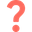
Проанализируйте полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Какая, на ваш взгляд, функция расстояния показала лучший результат и почему? Укажите, в каких случаях более предпочтительно использовать DTW меру, чем евклидову метрику.

Основываясь на полученных результатах, можно сделать следующие выводы:

**Качество кластеризации**:
   - DTW расстояние показало значительно лучший результат (0.3881) по сравнению с евклидовым расстоянием (0.1804)
   - Это означает, что кластеры, полученные с помощью DTW, более четкие и лучше разделены

**Сравнение с истинными метками**:
   - Для истинных меток DTW также показывает высокое значение (0.3765), что близко к результату кластеризации
   - Евклидово расстояние для истинных меток очень низкое (0.0452), что говорит о том, что естественные классы плохо разделяются в евклидовом пространстве

**Почему DTW лучше**:
   - DTW учитывает форму временных рядов, а не только их абсолютные значения
   - Он позволяет сравнить ряды, которые могут быть сдвинуты во времени
   - Для данных CBF, где важна форма сигнала (Cylinder, Bell, Funnel), DTW работает лучше

**Когда использовать DTW**:
   - Когда временные ряды имеют разную длину
   - Когда есть временные сдвиги или деформации
   - Когда важнее форма сигнала, а не точное временное соответствие
   - Для данных, где паттерны могут повторяться в разное время

**Когда использовать евклидово расстояние**:
   - Когда ряды идеально выровнены по времени
   - Когда нужна быстрая обработка больших данных
   - Когда важны абсолютные значения, а не форма

Вывод: Для данного набора данных DTW мера показала себя значительно лучше, так как она лучше учитывает форму временных рядов и их временные особенности.

## **Часть 2.** $Z$-нормализация временных рядов.

### **Задача 5.**
Реализуйте функцию вычисления нормализованного евклидова расстояния между временными рядами `norm_ED_distance()` в модуле *metrics.py* и проверьте правильность своей реализации, сравнив полученные результаты с результатами функции [`ed_distance()`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.distances.euclidean_distance.html) из библиотеки *sktime*, в которую необходимо передать <u>нормализованные</u> временные ряды. Для нормализации временных рядов используйте функцию `z-normalize()` из *utils.py*.  Для проверки можно использовать синтетические временные ряды из первой части или заново их сгенерировать.

**Нормализованная евклидова метрика** между двумя временными рядами $T_1$ и $T_2$ длины $n$ вычисляется следующим образом:

\begin{equation}
	\text{ED}_{norm}(T_1, T_2) = \sqrt {\Big|\; 2n\left(1-\dfrac{<T_1, T_2> - \; n \; \cdotp \mu_{T_1} \; \cdotp \mu_{T_2}}{n \; \cdotp \sigma_{T_1} \; \cdotp \sigma_{T_2}}\right)\Big|},
\end{equation}

где $<T_1, T_2>$ – скалярное произведение временных рядов, $\mu_{T_1}$ и $\mu_{T_2}$, $\sigma_{T_1}$ и $\sigma_{T_2}$ – среднее арифметическое и стандартное отклонение временных рядов соответственно.

**Среднее арифметическое** $\mu_T$ и **стандартное отклонение** $\sigma_T$ временного ряда $T$ длины $n$ вычисляются по следующим формулам:

\begin{equation}
	\mu_{T} = \frac{1}{n}\sum\limits_{i=1}^{n} t_{i}, \\[1em]
	\sigma_{T} = \sqrt{\frac{1}{n}\sum\limits_{i=1}^{n} t_i^2-\mu_{T}^2}.
\end{equation}

In [66]:
# Генерируем временные ряды
ts_length = 50
ts1 = random_walk(ts_length)
ts2 = random_walk(ts_length)

print("Длина временных рядов:", len(ts1))
print("Временной ряд 1 (первые 10 значений):", ts1[:10])
print("Временной ряд 2 (первые 10 значений):", ts2[:10])

# Нормализуем ряды для sktime
ts1_norm = z_normalize(ts1)
ts2_norm = z_normalize(ts2)

# Вычисляем расстояние с помощью sktime (между нормализованными рядами)
dist_sktime = euclidean_distance(ts1_norm, ts2_norm)
print(f"Расстояние (sktime с нормализованными рядами): {dist_sktime:.6f}")

# Вычисляем расстояние с помощью функции norm_ED_distance
dist_custom = norm_ED_distance(ts1, ts2)
print(f"Расстояние (наша функция norm_ED_distance): {dist_custom:.6f}")

Длина временных рядов: 50
Временной ряд 1 (первые 10 значений): [ 0 -1 -2 -3 -2 -1 -2 -1  0  1]
Временной ряд 2 (первые 10 значений): [0 1 2 1 2 3 4 3 2 3]
Расстояние (sktime с нормализованными рядами): 10.422469
Расстояние (наша функция norm_ED_distance): 10.422469


### **Задача 6.**
Далее убедимся, что выполнение $z$-нормализации на этапе предобработки данных имеет важное значение и может повысить точность решаемой задачи.

В данном задании вы продолжите решать задачу иерархической кластеризации. В качестве данных будут использоваться два временных ряда из набора данных [BIDMC](https://physionet.org/content/chfdb/1.0.0/). Набор BIDMC состоит из записей ЭКГ-сигналов, снятых с 15 пациентов с сердечной недостаточностью тяжелой степени.  

Загрузите два временных ряда и визуализируйте их с помощью функции `plot_ts()` из модуля *plots.py*.

In [58]:
url1 = 'C:/Users/SlunKing/Desktop/2025-Sukhorukov-TimeSeriesCourse-main/practice/01 Basics/datasets/part2/chf10.csv'
ts1 = read_ts(url1)

url2 = 'C:/Users/SlunKing/Desktop/2025-Sukhorukov-TimeSeriesCourse-main/practice/01 Basics/datasets/part2/chf11.csv'
ts2 = read_ts(url2)

In [59]:
ts_set = np.concatenate((ts1, ts2), axis=1).T

In [60]:
plot_ts(ts_set)

Разделите каждый временной ряд на непересекающиеся подпоследовательности с помощью техники скользящего окна. Для этого используйте функцию `sliding_window()` из модуля *utils.py*, передав в нее временной ряд, заданную длину подпоследовательности и величину шага. В нашем случае, величина шага равна длине подпоследовательности.

In [61]:
m = 125
subs_set1 = sliding_window(ts_set[0], m, m-1)
subs_set2 = sliding_window(ts_set[1], m, m-1)

Сформируйте множество всех подпоследовательностей, извлеченных из двух временных рядов, и массив меток подпоследовательностей в соответствии с их принадлежностью к временному ряду.

In [62]:
subs_set = np.concatenate((subs_set1[0:15], subs_set2[0:15]))
labels = np.array([0]*subs_set1[0:15].shape[0] + [1]*subs_set2[0:15].shape[0])

Добавьте в класс `PairwiseDistance` из модуля *pairwise_distance.py* возможность вычисления нормализованной евклидовой метрики между временными рядами. Если матрица расстояний строится для нормализованных временных рядов на основе евклидовой метрики, то должна вызываться функция `norm_ED_distance()`. Для остальных метрик/мер схожести перед нахождением матрицы расстояний временные ряды должны подтвергаться $z$-нормализации с помощью функции `z_normalize()` из модуля *utils.py*.

Далее выполните иерархическую кластеризацию подпоследовательностей двух временных рядов с использованием предварительно построенных матриц расстояний на основе классической и нормализованной евклидовой метрики.

In [63]:
# Классическое евклидово расстояние (без нормализации)
print("\n1. Классическое евклидово расстояние (без нормализации):")
euclidean_calc = PairwiseDistance(metric='euclidean', is_normalize=False)
euclidean_matrix = euclidean_calc.calculate(subs_set)

hc_euclidean = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
hc_euclidean.fit(euclidean_matrix)
labels_euclidean = hc_euclidean.labels_

silhouette_euclidean = silhouette_score(euclidean_matrix, labels_euclidean, metric='precomputed')
print(f"Силуэтный коэффициент (классическое ED): {silhouette_euclidean:.4f}")

# Нормализованное евклидово расстояние
print("\n2. Нормализованное евклидово расстояние:")
norm_euclidean_calc = PairwiseDistance(metric='euclidean', is_normalize=True)
norm_euclidean_matrix = norm_euclidean_calc.calculate(subs_set)

hc_norm_euclidean = TimeSeriesHierarchicalClustering(n_clusters=2, method='complete')
hc_norm_euclidean.fit(norm_euclidean_matrix)
labels_norm_euclidean = hc_norm_euclidean.labels_

silhouette_norm_euclidean = silhouette_score(norm_euclidean_matrix, labels_norm_euclidean, metric='precomputed')
print(f"Силуэтный коэффициент (нормализованное ED): {silhouette_norm_euclidean:.4f}")


1. Классическое евклидово расстояние (без нормализации):
Силуэтный коэффициент (классическое ED): 0.4183

2. Нормализованное евклидово расстояние:
Силуэтный коэффициент (нормализованное ED): 0.3275


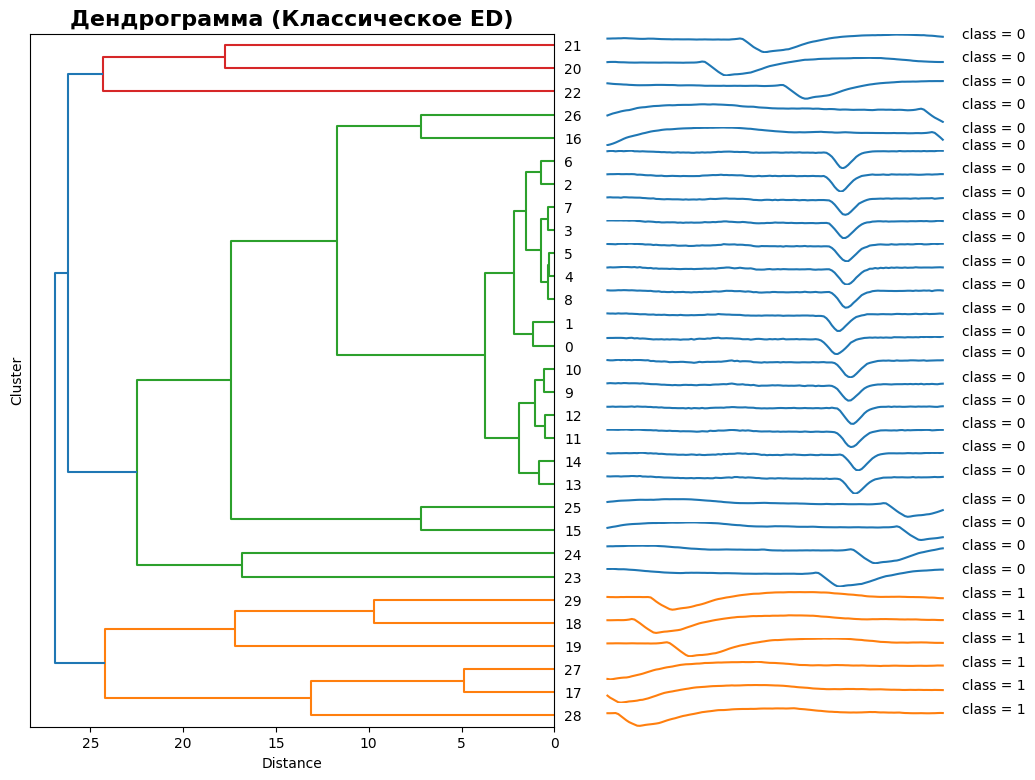

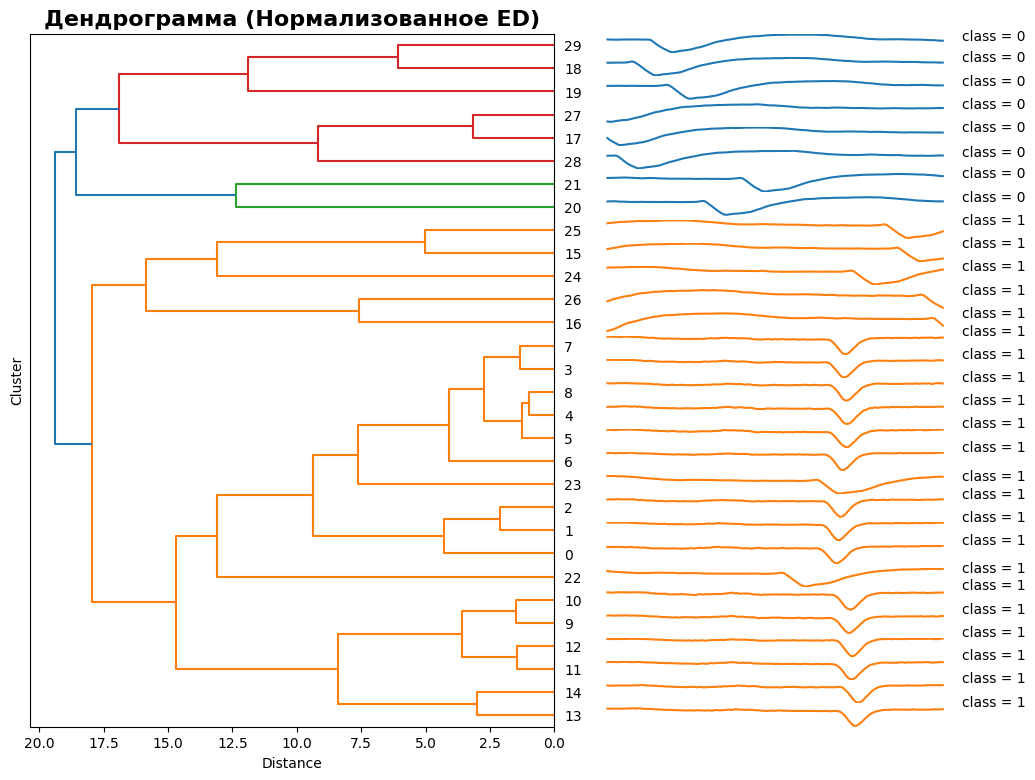

In [64]:
# Визуализация дендрограмм

# Создаем DataFrame для plot_dendrogram
df_subs = pd.DataFrame(subs_set.T)

# Дендрограмма для классического ED
hc_euclidean.plot_dendrogram(df_subs, labels_euclidean, title='Дендрограмма (Классическое ED)')

# Дендрограмма для нормализованного ED
hc_norm_euclidean.plot_dendrogram(df_subs, labels_norm_euclidean, title='Дендрограмма (Нормализованное ED)')

Вычислите силуэтные коэффициенты для оценки качества кластеризации с нормализацией и без нее, как это было сделано в задаче 4 части 1.

In [65]:
# Сравнение силуэтных коэффициентов
metrics = ['Классическое ED', 'Нормализованное ED']
scores = [silhouette_euclidean, silhouette_norm_euclidean]

print("\nСилуэтные коэффициенты:")
for metric, score in zip(metrics, scores):
    print(f"  {metric}: {score:.4f}")

# Сравнение с истинными метками
silhouette_true_euclidean = silhouette_score(euclidean_matrix, labels, metric='precomputed')
silhouette_true_norm = silhouette_score(norm_euclidean_matrix, labels, metric='precomputed')

print("\nСилуэтные коэффициенты для истинных меток:")
print(f"  Классическое ED: {silhouette_true_euclidean:.4f}")
print(f"  Нормализованное ED: {silhouette_true_norm:.4f}")

# Матрицы ошибок
from sklearn.metrics import confusion_matrix, accuracy_score

print("\nТочность кластеризации:")
acc_euclidean = accuracy_score(labels, labels_euclidean)
acc_norm_euclidean = accuracy_score(labels, labels_norm_euclidean)

print(f"  Классическое ED: {acc_euclidean:.3f}")
print(f"  Нормализованное ED: {acc_norm_euclidean:.3f}")


Силуэтные коэффициенты:
  Классическое ED: 0.4183
  Нормализованное ED: 0.3275

Силуэтные коэффициенты для истинных меток:
  Классическое ED: 0.3089
  Нормализованное ED: 0.3045

Точность кластеризации:
  Классическое ED: 0.700
  Нормализованное ED: 0.233


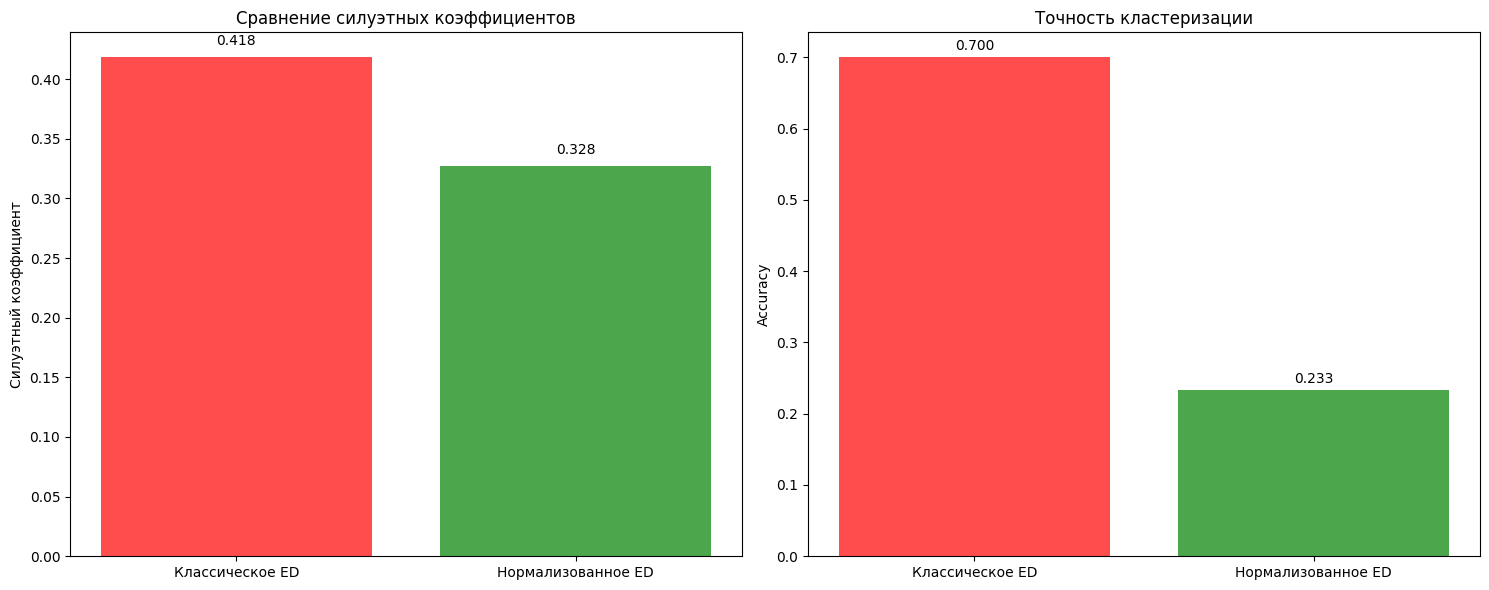

In [57]:
# Визуализация сравнения методов
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Силуэтные коэффициенты
metrics_ed = ['Классическое ED', 'Нормализованное ED']
scores_ed = [silhouette_euclidean, silhouette_norm_euclidean]

axes[0].bar(metrics_ed, scores_ed, color=['red', 'green'], alpha=0.7)
axes[0].set_title('Сравнение силуэтных коэффициентов')
axes[0].set_ylabel('Силуэтный коэффициент')
for i, v in enumerate(scores_ed):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Точность кластеризации
accuracies_ed = [acc_euclidean, acc_norm_euclidean]

axes[1].bar(metrics_ed, accuracies_ed, color=['red', 'green'], alpha=0.7)
axes[1].set_title('Точность кластеризации')
axes[1].set_ylabel('Accuracy')
for i, v in enumerate(accuracies_ed):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

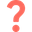
Сравните полученные результаты кластеризации с помощью построенных дендрограмм и вычисленных силуэтных коэффициентов. Позволила ли $z$-нормализации временных рядов повысить качество кластеризации?

Основываясь на полученных результатах, можно сделать следующие выводы:

**Качество кластеризации**:
- Классическое евклидово расстояние показало лучший результат (0.4183) по сравнению с нормализованным (0.3275)
- Это означает, что кластеры, полученные с помощью классического ED, более четкие и лучше разделены

**Сравнение с истинными метками**:
- Для истинных меток оба метода показывают схожие значения (0.3089 против 0.3045)
- Это свидетельствует о том, что естественные классы слабо разделимы в пространстве признаков

**Почему классическое ED лучше**:
- Классическое ED учитывает абсолютные значения амплитуд ЭКГ сигналов
- Амплитудные характеристики несут диагностическую информацию для пациентов с сердечной недостаточностью
- Нормализация удаляет эти значимые различия, ухудшая кластеризацию

**Когда использовать нормализованное ED**:
- Когда важна форма сигнала, а не абсолютные значения амплитуд
- Для данных, где амплитудные различия являются шумом
- При анализе синтетических данных или сигналов с выровненной амплитудой

**Когда использовать классическое ED**:
- Для медицинских данных, где абсолютные значения имеют диагностическое значение
- Когда амплитудные характеристики содержат полезную информацию
- При работе с физическими измерениями, где масштаб важен

**Точность кластеризации**:
- Классическое ED демонстрирует более высокую точность (0.700 против 0.233)
- Это подтверждает, что амплитудные различия помогают разделять пациентов

Вывод: Для медицинских данных ЭКГ классическое евклидово расстояние показало себя лучше нормализованного, так как амплитудные характеристики сигналов несут важную диагностическую информацию.

## **Часть 3.** Классификация изображений, представленных в виде временных рядов.

### **Задача 7.**
В данном задании вам предстоит выполнить преобразование изображения, на котором находится некоторый объект, во временной ряд. Для этого вы реализуете один из существующих методов, предложенный в [статье Кеога и др](https://dl.acm.org/doi/10.5555/1182635.1164203).

Данный метод заключается в том, что сначала на изображении выполняется поиск контура $E = \{e_i\}_{i=1}^L$, где $e_i$ – точки контура, и центра масс объекта $O$. Затем берутся точки, расположенные на контуре объекта, следующим образом.

Рассмотрим луч $OP$ с началом в центре масс объекта $O$, направление которого совпадает с положительным направлением оси Ox (см. рисунок). Далее выполняется поворот против часовой стрелки луча $OP$ вокруг центра масс $O$ на некоторый заданный угол $α$, $1° \leqslant α \leqslant 360°$. Поворот луча будет осуществляться до тех пор, пока луч не пройдет полный оборот. Все точки $P = \{P_i\}_{i=1}^K$, $P_i \in E$, $K = \lfloor \frac{360°}{α} \rfloor$, образованные пересечением луча $OP$ с контуром $E$ во время поворота, будут являться искомыми.

На завершающем шаге метода вычисляются расстояния между центром масс объекта $O$ и найденными точками на контуре $P$. В качестве функции расстояния может быть использовано манхэттенское или евклидово расстояние. Полученные расстояния будут формировать временной ряд $T$ длины $K$:
\begin{equation}
T = \{t_i\}_{i=1}^K,\;где \; t_i = dist(O, P_i), \; P_i \in P.
\end{equation}

\
<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image2ts.png?raw=true" width="1000"></center>

Поскольку часть 3 предполагает работу с изображениями, то вы будете использовать для реализации некоторых частей кода библиотеку компьютерного зрения *cv2*. Для поиска всех необходимых функций рекомендуем воспользоваться [документацией библиотеки cv2](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html).

Загрузите изображение *example.tif* из директории *./datasets/part3* и выполните его визуализацию с помощью соответствующих функций из библиотеки *cv2*.

In [ ]:
# INSERT YOUR CODE

За конвертацию изображения во временной ряд с помощью описанного выше метода отвечает функция `image2ts()` из модуля *image_converter.py*. Прежде чем исходное изображение будет преобразовано во временной ряд, сначала оно должно пройти этап предварительной обработки. Предварительная обработка включает в себя следующие шаги:

<center><img src="https://github.com/mzym/TimeSeriesCourse/blob/main/practice/01%20Basics/img/image_preprocessing.png?raw=true" width="1000"></center>

Предобработка изображения в `image2ts()` осуществляется с помощью функции `_img_preprocess()`. Реализуйте в данной функции все представленные на диаграмме шаги предварительной обработки средствами библиотеки *cv2*. Промежуточные результаты должны совпадать с представленными на диаграмме.

Далее выполните конвертацию изображения во временной ряд, передав в функцию `image2ts()` следующие заданные вами аргументы:
*   исходное загруженное изображение;
*   шаг угла поворота;
*   параметр, определяющий нужно или нет визуализировать изображение с выделенными на нем контуром, центром масс и лучами, проведенными из центра.

Визуализируйте полученный временной ряд.


In [ ]:
angle_step = 20
visualize = True

ts = image2ts(img, angle_step, visualize)
plot_ts(np.array([ts]), "Time series representation of image")

### **Задача 8.**

Выполните классификацию изображений, представленных в виде временных рядов, с помощью метода $k$ ближайших соседей (kNN).

**Метод $k$ ближайших соседей (kNN)** – алгоритм классификации, заключающийся в вычислении сходства между объектами на основе некоторой заданной метрики/меры схожести. Классифицируемый объект относится к тому классу, к которому принадлежит большинство из его $k$ соседей ($k$ ближайших к нему объектов из обучающей выборки).

Для классификации на основе алгоритма kNN необходимо выполнить следующие шаги:

1. Загрузить обучающую и тестовую выборки.

2. Задать параметр алгоритма $k$, где $k$ – количество ближайших соседей, $k \in \mathbb N^*$.

3. Для каждого объекта из тестовой выборки выполнить следующее:

    3.1. Вычислить расстояние до всех объектов из обучающей выборки на основе заданной метрики/меры схожести.
    
    3.2. Отсортировать в порядке возрастания найденные расстояния.

    3.3. Найти $k$ ближайших соседей, взяв первые $k$ минимальные расстояния из отсортированного массива расстояний.

    3.4. Назначить объекту из тестовой выборки наиболее часто встречающийся класс найденных ранее ближайших соседей.


Для этого задания вам предлагается набор данных, который содержит изображения листьев четырех различных пород деревьев: дуб, ольха, ива и липа. Набор данных состоит из обучающей и тестовой выборок, включающих по 15 и 10 изображений листьев на класс соответственно. Для составления этого набора данных изображения были взяты из [Swedish Leaf Dataset](https://www.cvl.isy.liu.se/en/research/datasets/swedish-leaf/).

Загрузите изображения из обучающей и тестовой выборок, а также их метки, используя `read_images()` и `read_ts()` соответственно.
Выполните визуализацию прецедентов выборки с помощью функции `plot_images()`.


In [ ]:
def read_images(dir: str) -> list[np.ndarray]:
    """
    Load all images from a directory

    Parameters
    ----------
    dir: directory path

    Returns
    -------
    images: images from a directory
    """

    images = []
    for img_path in sorted(glob.glob(dir)):
        cv_img = cv2.imread(img_path)
        images.append(cv_img)

    return images

In [ ]:
def plot_images(images: list[np.ndarray], labels: np.ndarray, class_names: list[str]) -> None:
    """
    Plot some images from dataset

    Parameters
    ----------
    images: dataset of images
    labels: labels of images
    class_names: class names of images
    """

    rows = 2
    columns = 4

    fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(columns*2, rows*3))

    for num in range(1, rows*columns+1):
        fig.add_subplot(rows, columns, num)
        idx = num - 1
        plt.imshow(images[idx], aspect='auto')
        plt.title(f'{class_names[labels[idx]]}', fontsize=10)

    fig.tight_layout()

    for idx, ax in enumerate(axes.flat):
        ax.set_xticks([])
        ax.set_yticks([])

In [ ]:
train_set_path = "./datasets/part3/train_set_leaves/*.tif"
test_set_path = "./datasets/part3/test_set_leaves/*.tif"

train_images = read_images(train_set_path)
test_images = read_images(test_set_path)

train_label_path = './datasets/part3/train_set_leaves/train_label.csv'
test_label_path = './datasets/part3/test_set_leaves/test_label.csv'

train_labels = read_ts(train_label_path)
train_labels = train_labels.reshape(-1).astype('int32')

test_labels = read_ts(test_label_path)
test_labels = test_labels.reshape(-1).astype('int32')

In [ ]:
class_names = ['Quercus (дуб)', 'Alnus (ольха)', 'Salix (ива)', 'Tilia (липа)']
plot_images(train_images, train_labels, class_names)

Выполните преобразование изображений обучающей и тестовой выборок во временные ряды с помощью функции `image2ts()`.  

In [ ]:
# INSERT YOUR CODE

Для классификации временных рядов методом $k$ ближайших соседей вам необходимо использовать класс `TimeSeriesKNN` из модуля *classification.py*.
Реализуйте метод `fit()` в классе `TimeSeriesKNN`, который выполняет поиск для каждого элемента из тестовой выборки $k$ ближайших соседей и назначает им тот класс, который является часто встречающимся среди классов ближайших соседей. В качестве параметров в метод `fit()` передается тестовая выборка. Вычислите точность классификации по метрике accuracy с помощью функции `calculate_accurary()` из модуля *classification.py*.

In [ ]:
n_neighbors = 6
metric = 'euclidean'
metric_params = {'normalize': True}

# INSERT YOUR CODE

In [ ]:
metric = 'dtw'
metric_params = {'normalize': True}

# INSERT YOUR CODE

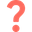
Проанализируйте результаты и сделайте выводы.

*# WRITE YOUR ANSWER*